<a href="https://colab.research.google.com/github/DulSamindika/XAI-for-Risk-Management/blob/main/research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get install -y mysql-server > /dev/null 2>&1
!service mysql start
print('MySQL server started successfully.')

# Install Python MySQL connector
!pip install mysql-connector-python -q
print('mysql-connector-python installed.')

# Install imbalanced-learn for SMOTE later
!pip install imbalanced-learn -q
print('imbalanced-learn installed.')

 * Starting MySQL database server mysqld
su: warning: cannot change directory to /nonexistent: No such file or directory
   ...done.
MySQL server started successfully.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 19.3 MB/s eta 0:00:00
mysql-connector-python installed.
imbalanced-learn installed.


In [ ]:
# Set MySQL root password (required for Python connection)
!mysql -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY 'tawos_root_2024'; FLUSH PRIVILEGES;"
print('Root password set: tawos_root_2024')

Root password set: tawos_root_2024


In [ ]:
from google.colab import files
import os

# OPTION A: Upload directly from your computer
# Uncomment the line below to use file upload dialog
# uploaded = files.upload()  # Select your .sql file
# SQL_FILE = list(uploaded.keys())[0]

# OPTION B: Mount Google Drive (recommended for large files)
from google.colab import drive
drive.mount('/content/drive')

# Set your path here — change folder name if different
SQL_FILE = '/content/drive/MyDrive/TAWOS/TAWOS.sql'

# Verify the file exists
if os.path.exists(SQL_FILE):
    size_mb = os.path.getsize(SQL_FILE) / (1024*1024)
    print(f'File found: {SQL_FILE}')
    print(f'File size:  {size_mb:.1f} MB')
else:
    print('FILE NOT FOUND — check your path')
    print('Expected path:', SQL_FILE)

Mounted at /content/drive
File found: /content/drive/MyDrive/TAWOS/TAWOS.sql
File size:  4114.0 MB


In [ ]:
import subprocess

# Create the database first
!mysql -u root -ptawos_root_2024 -e "CREATE DATABASE IF NOT EXISTS TAWOS;"
print('Database TAWOS created.')

# Import the SQL dump — this is the main loading step
print('Loading SQL file into MySQL... (this may take 5-15 minutes)')
result = subprocess.run(
    f'mysql -u root -ptawos_root_2024 TAWOS < "{SQL_FILE}"',
    shell=True, capture_output=True, text=True
)

if result.returncode == 0:
    print('SQL file loaded successfully!')
else:
    print('Error loading SQL file:')
    print(result.stderr)

# Verify tables loaded
!mysql -u root -ptawos_root_2024 -e "USE TAWOS; SHOW TABLES;"

mysql: [Warning] Using a password on the command line interface can be insecure.
Database TAWOS created.
Loading SQL file into MySQL... (this may take 5-15 minutes)
SQL file loaded successfully!
mysql: [Warning] Using a password on the command line interface can be insecure.
+------------------+
| Tables_in_TAWOS  |
+------------------+
| Affected_Version |
| Change_Log       |
| Comment          |
| Component        |
| Fix_Version      |
| Issue            |
| Issue_Component  |
| Issue_Link       |
| Project          |
| Repository       |
| Sprint           |
| User             |
| Version          |
+------------------+


In [ ]:
import mysql.connector
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='tawos_root_2024',
    database='TAWOS'
)
print('Connected to MySQL TAWOS database.')

def run_query(sql, conn=conn):
    """Helper: run a SQL query and return a DataFrame."""
    return pd.read_sql(sql, conn)

# Show all tables
tables = run_query('SHOW TABLES;')
print('\nTables in TAWOS database:')
print(tables.to_string(index=False))

Connected to MySQL TAWOS database.

Tables in TAWOS database:
 Tables_in_TAWOS
Affected_Version
      Change_Log
         Comment
       Component
     Fix_Version
           Issue
 Issue_Component
      Issue_Link
         Project
      Repository
          Sprint
            User
         Version


In [ ]:
# Get row counts for all tables
table_names = [
    'Repository', 'Project', 'User', 'Issue',
    'Sprint',
    'Comment', 'Change_Log',
    'Issue_Link', 'Component', 'Version'
]

print(f'{'Table':<25} {'Rows':>12}')
print('-' * 40)
for t in table_names:
    try:
        count = run_query(f'SELECT COUNT(*) as cnt FROM `{t}`;')['cnt'][0]
        print(f'{t:<25} {count:>12,}')
    except Exception as e:
        print(f'{t:<25} ERROR: {e}')

print('\n--- Issue table columns ---')
cols = run_query('DESCRIBE Issue;')
print(cols[['Field','Type']].to_string(index=False))

Table                             Rows
----------------------------------------
Repository                          12
Project                             39
User                           206,162
Issue                          458,232
Sprint                           4,594
Comment                      1,518,327
Change_Log                   9,253,419
Issue_Link                     246,587
Component                        2,001
Version                          6,911

--- Issue table columns ---
                               Field         Type
                                  ID          int
                             Jira_ID          int
                           Issue_Key varchar(512)
                                 URL varchar(512)
                               Title varchar(512)
                         Description   mediumtext
                    Description_Text   mediumtext
                    Description_Code   mediumtext
                                Type varchar(128)
 

In [ ]:
print('Extracting Issue table (technical features)...')

issues = run_query("""
    SELECT
        i.ID                                    AS issue_id,
        i.Project_ID                            AS project_id,
        i.Creator_ID                            AS creator_id,
        i.Issue_Key                             AS issue_key,
        i.Type                                  AS issue_type,
        i.Priority                              AS priority,
        i.Status                                AS status,
        i.Resolution                            AS resolution,
        i.Story_Point                           AS story_point,
        i.Timespent                             AS timespent,
        i.In_Progress_Minutes                   AS in_progress_minutes,
        i.Total_Effort_Minutes                  AS total_effort_minutes,
        i.Resolution_Time_Minutes                AS resolution_time_minutes,
        i.Creation_Date                         AS creation_date,
        i.Resolution_Date                       AS resolution_date,
        i.Story_Point_Changed_After_Estimation  AS sp_changed_after_est,
        i.Title_Changed_After_Estimation        AS title_changed_after_est,
        i.Description_Changed_After_Estimation  AS desc_changed_after_est,
        i.Sprint_ID                             AS sprint_id
    FROM Issue i
    WHERE i.Story_Point IS NOT NULL
      AND i.Story_Point > 0
""")

print(f'Issues loaded: {len(issues):,} rows')
print(f'Projects covered: {issues["project_id"].nunique()}')
print('\nSample:')
issues.head(3)

Extracting Issue table (technical features)...
Issues loaded: 63,011 rows
Projects covered: 39

Sample:


,issue_id,project_id,creator_id,issue_key,issue_type,priority,status,resolution,story_point,timespent,in_progress_minutes,total_effort_minutes,resolution_time_minutes,creation_date,resolution_date,sp_changed_after_est,title_changed_after_est,desc_changed_after_est,sprint_id
0,65,1,68.0,XD-3768,Bug,Major,To Do,None,1.0,NaN,0.0,0.0,0.0,2017-07-10 13:41:25,NaT,0,0,0,NaN
1,66,1,69.0,XD-3767,Bug,Trivial,To Do,None,1.0,NaN,0.0,0.0,0.0,2017-06-26 16:26:27,NaT,0,0,0,NaN
2,67,1,70.0,XD-3766,Bug,Major,To Do,None,10.0,NaN,0.0,0.0,0.0,2017-05-19 22:28:43,NaT,0,0,0,NaN


In [ ]:
print('Extracting Sprint table...')

sprints = run_query("""
    SELECT
        s.ID          AS sprint_id,
        s.Project_ID  AS project_id,
        s.Name        AS sprint_name,
        s.State       AS sprint_state,
        s.Start_Date  AS sprint_start,
        s.End_Date    AS sprint_end,
        s.Complete_Date AS sprint_completed
    FROM Sprint s
    WHERE s.State = 'closed'
""")

print(f'Closed sprints loaded: {len(sprints):,}')


Extracting Sprint table...
Closed sprints loaded: 4,507


In [ ]:
print('Joining Issues and Sprints...')

issues_with_sprint = pd.merge(
    issues,
    sprints[['sprint_id', 'sprint_name', 'sprint_start', 'sprint_end', 'sprint_completed']],
    on='sprint_id',
    how='left'
)

print(f'Issues with sprint info loaded: {len(issues_with_sprint):,} rows')
print('\nSample:')
issues_with_sprint.head(3)

Joining Issues and Sprints...
Issues with sprint info loaded: 63,011 rows

Sample:


,issue_id,project_id,creator_id,issue_key,issue_type,priority,status,resolution,story_point,timespent,...,creation_date,resolution_date,sp_changed_after_est,title_changed_after_est,desc_changed_after_est,sprint_id,sprint_name,sprint_start,sprint_end,sprint_completed
0,65,1,68.0,XD-3768,Bug,Major,To Do,None,1.0,NaN,...,2017-07-10 13:41:25,NaT,0,0,0,NaN,NaN,NaN,NaN,NaT
1,66,1,69.0,XD-3767,Bug,Trivial,To Do,None,1.0,NaN,...,2017-06-26 16:26:27,NaT,0,0,0,NaN,NaN,NaN,NaN,NaT
2,67,1,70.0,XD-3766,Bug,Major,To Do,None,10.0,NaN,...,2017-05-19 22:28:43,NaT,0,0,0,NaN,NaN,NaN,NaN,NaT


In [ ]:
print('Extracting Change_Log table (human + process factors)...')
print('NOTE: This table is large — may take 1-2 minutes...')

changelogs = run_query("""
    SELECT
        cl.Issue_ID     AS issue_id,
        cl.Change_Type  AS change_type,
        cl.Creation_Date AS change_date
    FROM Change_Log cl
    WHERE cl.Change_Type IN ('PEOPLE', 'STATUS', 'STORY_POINT', 'DESCRIPTION')
""")

print(f'Change logs loaded: {len(changelogs):,}')
print('\nBreakdown by change type:')
print(changelogs['change_type'].value_counts().to_string())

Extracting Change_Log table (human + process factors)...
NOTE: This table is large — may take 1-2 minutes...
Change logs loaded: 2,526,526

Breakdown by change type:
change_type
STATUS         1779677
PEOPLE          349551
DESCRIPTION     348103
STORY_POINT      49195


In [ ]:
print('Extracting Issue_Link table (process dependency factor)...')

issue_links = run_query("""
    SELECT Issue_ID AS issue_id
    FROM Issue_Link
""")

print(f'Issue links loaded: {len(issue_links):,}')

Extracting Issue_Link table (process dependency factor)...
Issue links loaded: 246,587


In [ ]:
# ─── TECHNICAL FEATURES (already in issues table) ───────────────────────────
tech_cols = [
    'issue_id', 'project_id', 'creator_id',
    'issue_type', 'priority', 'status', 'resolution',
    'story_point', 'timespent', 'in_progress_minutes',
    'total_effort_minutes', 'resolution_time_minutes',
    'sp_changed_after_est', 'title_changed_after_est', 'desc_changed_after_est'
]
tech_df = issues[tech_cols].copy()

# Convert booleans stored as 0/1 or True/False
bool_cols = ['sp_changed_after_est', 'title_changed_after_est', 'desc_changed_after_est']
for col in bool_cols:
    tech_df[col] = pd.to_numeric(tech_df[col], errors='coerce').fillna(0).astype(int)

# Binary: is this issue a bug?
tech_df['is_bug'] = (tech_df['issue_type'].str.lower() == 'bug').astype(int)

# Binary: is this issue high priority?
tech_df['is_high_priority'] = (
    tech_df['priority'].str.lower().isin(['highest', 'critical', 'blocker'])
).astype(int)

# Effort overrun: actual effort minus estimated (story_point * 60 mins)
tech_df['effort_overrun'] = (
    tech_df['total_effort_minutes'].fillna(0) -
    (tech_df['story_point'].fillna(0) * 60)
).clip(lower=0)

print('Technical features prepared.')
print(f'Shape: {tech_df.shape}')
print(tech_df[['issue_id','story_point','is_bug','effort_overrun']].head(3))

Technical features prepared.
Shape: (63011, 18)
   issue_id  story_point  is_bug  effort_overrun
0        65          1.0       1             0.0
1        66          1.0       1             0.0
2        67         10.0       1             0.0


In [ ]:
print('Extracting Comment table...')
comments = run_query("""
    SELECT
        c.Issue_ID AS issue_id,
        c.Author_ID AS Author_ID,
        c.Creation_Date AS comment_date
    FROM Comment c
""")

print(f'Comments loaded: {len(comments):,} rows')
print('\nSample:')
comments.head(3)

print('\nDescribing the Comment table to find correct column names:')
comment_schema = run_query('DESCRIBE Comment;')
print(comment_schema[['Field', 'Type']].to_string(index=False))

Extracting Comment table...
Comments loaded: 1,518,327 rows

Sample:

Describing the Comment table to find correct column names:
        Field       Type
           ID        int
      Comment mediumtext
 Comment_Text mediumtext
 Comment_Code mediumtext
Creation_Date   datetime
    Author_ID        int
     Issue_ID        int


In [ ]:
print('Run the cell oKPd5TZqNwNR again.')
# ─── HUMAN FEATURES (from Change_Log + Comment) ──────────────────────────────

# Reassignments per issue (PEOPLE changes = team instability)
people_chg = changelogs[changelogs['change_type'] == 'PEOPLE']
reassignments = people_chg.groupby('issue_id').size().reset_index(name='reassignment_count')

# Status transitions per issue (workflow churn = process instability — also human indicator)
status_chg = changelogs[changelogs['change_type'] == 'STATUS']
status_churn = status_chg.groupby('issue_id').size().reset_index(name='status_change_count')

# Comment volume per issue (communication intensity)
comment_vol = comments.groupby('issue_id').size().reset_index(name='comment_count')

# Unique commenters per issue (collaboration breadth)
unique_commenters = comments.groupby('issue_id')['Author_ID'].nunique().reset_index(
    name='unique_commenters')

# Merge all human signals onto issues
human_df = tech_df[['issue_id']].copy()
human_df = human_df.merge(reassignments,     on='issue_id', how='left')
human_df = human_df.merge(status_churn,      on='issue_id', how='left')
human_df = human_df.merge(comment_vol,       on='issue_id', how='left')
human_df = human_df.merge(unique_commenters, on='issue_id', how='left')
human_df = human_df.fillna(0)

print('Human features prepared.')
print(f'Shape: {human_df.shape}')
print(human_df.describe().round(2))

Run the cell oKPd5TZqNwNR again.
Human features prepared.
Shape: (63011, 5)
        issue_id  reassignment_count  status_change_count  comment_count  \
count   63011.00            63011.00             63011.00       63011.00   
mean   231486.67                1.08                 4.63           3.14   
std    137440.19                1.88                 3.27           5.74   
min        65.00                0.00                 0.00           0.00   
25%    176537.50                0.00                 3.00           1.00   
50%    237300.00                1.00                 4.00           2.00   
75%    345858.50                1.00                 5.00           4.00   
max    505453.00               41.00                65.00         186.00   

       unique_commenters  
count           63011.00  
mean                1.71  
std                 2.25  
min                 0.00  
25%                 1.00  
50%                 1.00  
75%                 2.00  
max               118.0

In [ ]:
# ─── PROCESS FEATURES (from Change_Log + Issue_Link) ─────────────────────────

# Story point changes (scope volatility)
sp_chg = changelogs[changelogs['change_type'] == 'STORY_POINT']
sp_volatility = sp_chg.groupby('issue_id').size().reset_index(name='sp_change_count')

# Description/title changes (requirement volatility)
desc_chg = changelogs[changelogs['change_type'] == 'DESCRIPTION']
req_volatility = desc_chg.groupby('issue_id').size().reset_index(name='req_change_count')

# Dependency count (process complexity)
dependency_count = issue_links.groupby('issue_id').size().reset_index(name='dependency_count')

# Merge all process signals
process_df = tech_df[['issue_id',
                       'sp_changed_after_est',
                       'desc_changed_after_est']].copy()
process_df = process_df.merge(sp_volatility,    on='issue_id', how='left')
process_df = process_df.merge(req_volatility,   on='issue_id', how='left')
process_df = process_df.merge(dependency_count, on='issue_id', how='left')
process_df = process_df.fillna(0)

print('Process features prepared.')
print(f'Shape: {process_df.shape}')
print(process_df.describe().round(2))

Process features prepared.
Shape: (63011, 6)
        issue_id  sp_changed_after_est  desc_changed_after_est  \
count   63011.00              63011.00                 63011.0   
mean   231486.67                  0.12                     0.0   
std    137440.19                  0.33                     0.0   
min        65.00                  0.00                     0.0   
25%    176537.50                  0.00                     0.0   
50%    237300.00                  0.00                     0.0   
75%    345858.50                  0.00                     0.0   
max    505453.00                  1.00                     0.0   

       sp_change_count  req_change_count  dependency_count  
count         63011.00          63011.00          63011.00  
mean              0.71              0.79              0.64  
std               0.76              1.70              1.34  
min               0.00              0.00              0.00  
25%               0.00              0.00              0

In [ ]:
# Combine all per-issue features into one dataframe
all_issue_features = tech_df.merge(human_df,   on='issue_id', how='left') \
                             .merge(process_df, on='issue_id', how='left')

# Join to sprint membership
sprint_issues = issues_with_sprint.merge(all_issue_features, on='issue_id', how='inner')

# Only keep issues in closed sprints
closed_sprint_ids = set(sprints['sprint_id'])
sprint_issues = sprint_issues[sprint_issues['sprint_id'].isin(closed_sprint_ids)]

print(f'Sprint-issue joined rows: {len(sprint_issues):,}')
print(f'Unique closed sprints:    {sprint_issues["sprint_id"].nunique():,}')
print(f'Unique projects:          {sprint_issues["project_id_x"].nunique()}')

Sprint-issue joined rows: 28,914
Unique closed sprints:    2,804
Unique projects:          36


In [ ]:
# ─── AGGREGATE TO SPRINT LEVEL ───────────────────────────────────────────────
sprint_df = sprint_issues.groupby('sprint_id').agg(

    # ── TECHNICAL FEATURES ──────────────────────────────────────────────────
    total_issues            = ('issue_id',               'count'),
    story_pts_planned       = ('story_point_x',            'sum'),
    bug_count               = ('is_bug',                 'sum'),
    high_priority_count     = ('is_high_priority',       'sum'),
    avg_resolution_mins     = ('resolution_time_minutes_x','mean'),
    avg_effort_mins         = ('total_effort_minutes_x',   'mean'),
    total_effort_overrun    = ('effort_overrun',         'sum'),
    scope_changed_count     = ('sp_changed_after_est_x',   'sum'),
    title_changed_count     = ('title_changed_after_est_x','sum'),

    # ── HUMAN FEATURES ──────────────────────────────────────────────────────
    unique_contributors     = ('creator_id_x',             'nunique'),
    total_reassignments     = ('reassignment_count',     'sum'),
    total_status_churn      = ('status_change_count',    'sum'),
    total_comments          = ('comment_count',          'sum'),
    avg_unique_commenters   = ('unique_commenters',      'mean'),

    # ── PROCESS FEATURES ────────────────────────────────────────────────────
    req_change_count        = ('req_change_count',       'sum'),
    sp_change_count         = ('sp_change_count',        'sum'),
    desc_changed_count      = ('desc_changed_after_est_x', 'sum'),
    total_dependencies      = ('dependency_count',       'sum'),

).reset_index()

# Derived ratios
sprint_df['bug_ratio']          = sprint_df['bug_count'] / sprint_df['total_issues'].replace(0,1)
sprint_df['high_priority_ratio']= sprint_df['high_priority_count'] / sprint_df['total_issues'].replace(0,1)
sprint_df['avg_story_pts']      = sprint_df['story_pts_planned'] / sprint_df['total_issues'].replace(0,1)
sprint_df['scope_change_ratio'] = sprint_df['scope_changed_count'] / sprint_df['total_issues'].replace(0,1)
sprint_df['reassignment_ratio'] = sprint_df['total_reassignments'] / sprint_df['total_issues'].replace(0,1)

print(f'Sprint-level matrix shape: {sprint_df.shape}')
print(sprint_df.head(3))

Sprint-level matrix shape: (2804, 24)
   sprint_id  total_issues  story_pts_planned  bug_count  high_priority_count  \
0        1.0             7               10.0          3                    0   
1        2.0             9               16.0          5                    0   
2        3.0             1                1.0          1                    1   

   avg_resolution_mins  avg_effort_mins  total_effort_overrun  \
0         75347.714286      3542.285714               24315.0   
1         46683.888889     16209.777778              145048.0   
2         10444.000000     10425.000000               10365.0   

   scope_changed_count  title_changed_count  ...  avg_unique_commenters  \
0                    0                    2  ...               0.428571   
1                    0                    1  ...               0.555556   
2                    0                    0  ...               0.000000   

   req_change_count  sp_change_count  desc_changed_count  total_dependencie

In [ ]:
# Story points actually completed (Status = 'Done' or Resolution is not null)
done_mask = (
    (sprint_issues['status_x'].str.lower() == 'done') |
    (sprint_issues['resolution_x'].notna() & (sprint_issues['resolution_x'].str.lower() != 'unresolved'))
)

done_pts = sprint_issues[done_mask].groupby('sprint_id')['story_point_x'].sum().reset_index()
done_pts.columns = ['sprint_id', 'story_pts_done']

sprint_df = sprint_df.merge(done_pts, on='sprint_id', how='left')
sprint_df['story_pts_done'] = sprint_df['story_pts_done'].fillna(0)

# Completion rate: 1.0 = 100% complete, 0.0 = nothing done
sprint_df['completion_rate'] = (
    sprint_df['story_pts_done'] /
    sprint_df['story_pts_planned'].replace(0, np.nan)
).fillna(0).clip(0, 1)

print('Completion rate stats:')
print(sprint_df['completion_rate'].describe().round(3))

Completion rate stats:
count    2804.000
mean        0.969
std         0.124
min         0.000
25%         1.000
50%         1.000
75%         1.000
max         1.000
Name: completion_rate, dtype: float64


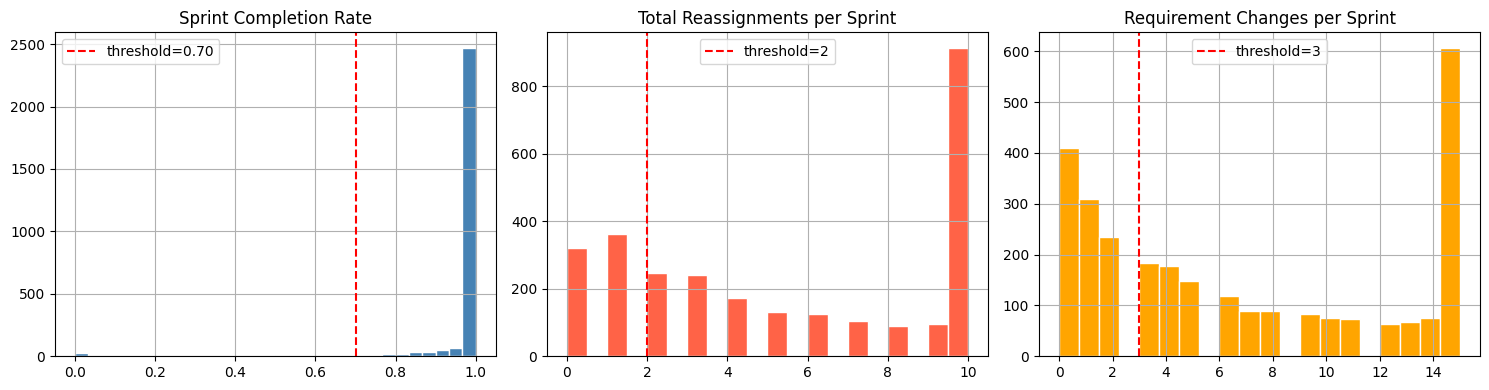

Chart saved to Google Drive.


In [ ]:
import matplotlib.pyplot as plt

# ── Check distributions BEFORE deciding thresholds ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sprint_df['completion_rate'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0.70, color='red', linestyle='--', label='threshold=0.70')
axes[0].set_title('Sprint Completion Rate')
axes[0].legend()

sprint_df['total_reassignments'].clip(0,10).hist(bins=20, ax=axes[1], color='tomato', edgecolor='white')
axes[1].axvline(2, color='red', linestyle='--', label='threshold=2')
axes[1].set_title('Total Reassignments per Sprint')
axes[1].legend()

sprint_df['req_change_count'].clip(0,15).hist(bins=20, ax=axes[2], color='orange', edgecolor='white')
axes[2].axvline(3, color='red', linestyle='--', label='threshold=3')
axes[2].set_title('Requirement Changes per Sprint')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TAWOS/threshold_distributions.png', dpi=150)
plt.show()
print('Chart saved to Google Drive.')

In [ ]:
# Step 1: print percentiles to see your actual data distribution
print("=== Completion Rate Percentiles ===")
print(sprint_df['completion_rate'].quantile([.25,.50,.75,.90]).round(3))

print("\n=== Reassignment Percentiles ===")
print(sprint_df['total_reassignments'].quantile([.25,.50,.75,.90]).round(1))

print("\n=== Req Change Percentiles ===")
print(sprint_df['req_change_count'].quantile([.25,.50,.75,.90]).round(1))

# Step 2: set thresholds at the 75th percentile of each signal
#         (top 25% = genuinely risky, bottom 75% = normal)
P75_COMPLETION  = sprint_df['completion_rate'].quantile(0.25)  # BELOW 25th = low
P75_REASSIGN    = sprint_df['total_reassignments'].quantile(0.75)
P75_REQ_CHANGES = sprint_df['req_change_count'].quantile(0.75)

print(f"\nDerived thresholds:")
print(f"  Completion rate below : {P75_COMPLETION:.2f}")
print(f"  Reassignments above   : {P75_REASSIGN:.0f}")
print(f"  Req changes above     : {P75_REQ_CHANGES:.0f}")

# Step 3: apply percentile-based label
sprint_df['is_high_risk'] = (
    (sprint_df['completion_rate']     < P75_COMPLETION)   |
    (sprint_df['total_reassignments'] > P75_REASSIGN)     |
    (sprint_df['req_change_count']    > P75_REQ_CHANGES)
).astype(int)

counts   = sprint_df['is_high_risk'].value_counts()
risk_rate = sprint_df['is_high_risk'].mean()
print(f"\nNew label distribution:")
print(f"  Low risk  (0): {counts.get(0,0):,}")
print(f"  High risk (1): {counts.get(1,0):,}")
print(f"  Risk rate    : {risk_rate:.1%}")
print()
if 0.20 <= risk_rate <= 0.60:
    print("Risk rate is now in the acceptable range (20%-60%).")
else:
    print("Still outside range — try quantile(0.80) for reassignments.")

=== Completion Rate Percentiles ===
0.25    1.0
0.50    1.0
0.75    1.0
0.90    1.0
Name: completion_rate, dtype: float64

=== Reassignment Percentiles ===
0.25     2.0
0.50     5.0
0.75    13.0
0.90    27.0
Name: total_reassignments, dtype: float64

=== Req Change Percentiles ===
0.25     1.0
0.50     5.0
0.75    13.0
0.90    24.0
Name: req_change_count, dtype: float64

Derived thresholds:
  Completion rate below : 1.00
  Reassignments above   : 13
  Req changes above     : 13

New label distribution:
  Low risk  (0): 1,717
  High risk (1): 1,087
  Risk rate    : 38.8%

Risk rate is now in the acceptable range (20%-60%).


In [ ]:
# ── Final feature columns split by dimension ─────────────────────────────────
TECHNICAL_FEATURES = [
    'total_issues', 'story_pts_planned', 'bug_count', 'bug_ratio',
    'high_priority_count', 'high_priority_ratio',
    'avg_resolution_mins', 'avg_effort_mins', 'total_effort_overrun',
    'scope_changed_count', 'scope_change_ratio',
    'title_changed_count', 'avg_story_pts', 'story_pts_done', 'completion_rate'
]

HUMAN_FEATURES = [
    'unique_contributors', 'total_reassignments', 'reassignment_ratio',
    'total_status_churn', 'total_comments', 'avg_unique_commenters'
]

PROCESS_FEATURES = [
    'req_change_count', 'sp_change_count',
    'desc_changed_count', 'total_dependencies'
]

ALL_FEATURES = TECHNICAL_FEATURES + HUMAN_FEATURES + PROCESS_FEATURES

# ── Remove sprints with no story points (unusable for completion rate) ────────
final_df = sprint_df[sprint_df['story_pts_planned'] > 0].copy()

# ── Drop rows missing more than 3 feature values ─────────────────────────────
final_df = final_df.dropna(subset=ALL_FEATURES, thresh=len(ALL_FEATURES) - 3)

# ── Fill remaining nulls with 0 ───────────────────────────────────────────────
final_df[ALL_FEATURES] = final_df[ALL_FEATURES].fillna(0)

# ── Remove zero-variance columns (will break ML models) ──────────────────────
low_var_cols = [c for c in ALL_FEATURES
                if final_df[c].std() == 0]
if low_var_cols:
    print(f'Dropping zero-variance columns: {low_var_cols}')
    ALL_FEATURES = [c for c in ALL_FEATURES if c not in low_var_cols]

print(f'Final dataset: {len(final_df):,} sprints × {len(ALL_FEATURES)} features')
print(f'Class balance: {final_df["is_high_risk"].value_counts().to_dict()}')

Dropping zero-variance columns: ['desc_changed_count']
Final dataset: 2,804 sprints × 24 features
Class balance: {0: 1717, 1: 1087}


In [ ]:
OUTPUT_PATH = '/content/drive/MyDrive/TAWOS/'

# 1. Full labelled dataset (all features + label)
full_out = final_df[['sprint_id'] + ALL_FEATURES + ['is_high_risk']]
full_out.to_csv(OUTPUT_PATH + '01_sprint_risk_full.csv', index=False)
print(f'Saved: 01_sprint_risk_full.csv  ({len(full_out):,} rows)')

# 2. Technical features only
tech_out = final_df[['sprint_id'] + TECHNICAL_FEATURES + ['is_high_risk']]
tech_out.to_csv(OUTPUT_PATH + '02_technical_features.csv', index=False)
print(f'Saved: 02_technical_features.csv')

# 3. Human features only
human_out = final_df[['sprint_id'] + HUMAN_FEATURES + ['is_high_risk']]
human_out.to_csv(OUTPUT_PATH + '03_human_features.csv', index=False)
print(f'Saved: 03_human_features.csv')

# 4. Process features only
proc_out = final_df[['sprint_id'] + PROCESS_FEATURES + ['is_high_risk']]
proc_out.to_csv(OUTPUT_PATH + '04_process_features.csv', index=False)
print(f'Saved: 04_process_features.csv')

# 5. Feature dictionary (for your thesis methodology section)
feature_dict = (
    [{'feature': f, 'dimension': 'Technical'} for f in TECHNICAL_FEATURES] +
    [{'feature': f, 'dimension': 'Human'}     for f in HUMAN_FEATURES]     +
    [{'feature': f, 'dimension': 'Process'}   for f in PROCESS_FEATURES]
)
pd.DataFrame(feature_dict).to_csv(OUTPUT_PATH + '05_feature_dictionary.csv', index=False)
print(f'Saved: 05_feature_dictionary.csv')

print('\nAll files saved to Google Drive TAWOS folder.')

Saved: 01_sprint_risk_full.csv  (2,804 rows)
Saved: 02_technical_features.csv
Saved: 03_human_features.csv
Saved: 04_process_features.csv
Saved: 05_feature_dictionary.csv

All files saved to Google Drive TAWOS folder.


  TAWOS DATASET PREPARATION SUMMARY
  Total sprints in final dataset  :  2,804
  Total features                  :     24
    Technical features            :     15
    Human features                :      6
    Process features              :      4
  Low risk sprints  (label=0)     :  1,717
  High risk sprints (label=1)     :  1,087
  Overall risk rate               :  38.8%

Output files saved:
  01_sprint_risk_full.csv     — full feature matrix
  02_technical_features.csv   — technical factors only
  03_human_features.csv       — human factors only
  04_process_features.csv     — process factors only
  05_feature_dictionary.csv   — feature labels for thesis


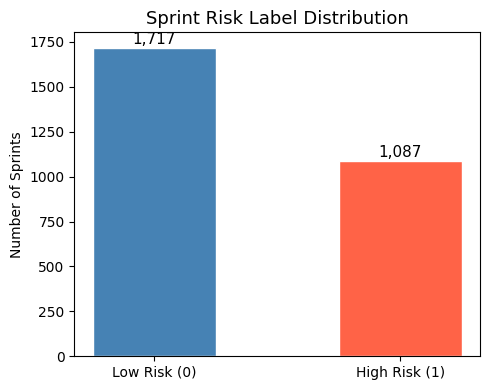

Chart saved.


In [ ]:
import matplotlib.pyplot as plt

print('=' * 55)
print('  TAWOS DATASET PREPARATION SUMMARY')
print('=' * 55)
print(f'  Total sprints in final dataset  : {len(final_df):>6,}')
print(f'  Total features                  : {len(ALL_FEATURES):>6}')
print(f'    Technical features            : {len(TECHNICAL_FEATURES):>6}')
print(f'    Human features                : {len(HUMAN_FEATURES):>6}')
print(f'    Process features              : {len(PROCESS_FEATURES):>6}')
print(f'  Low risk sprints  (label=0)     : {(final_df["is_high_risk"]==0).sum():>6,}')
print(f'  High risk sprints (label=1)     : {(final_df["is_high_risk"]==1).sum():>6,}')
print(f'  Overall risk rate               : {final_df["is_high_risk"].mean():>6.1%}')
print('=' * 55)
print()
print('Output files saved:')
print('  01_sprint_risk_full.csv     — full feature matrix')
print('  02_technical_features.csv   — technical factors only')
print('  03_human_features.csv       — human factors only')
print('  04_process_features.csv     — process factors only')
print('  05_feature_dictionary.csv   — feature labels for thesis')

# Plot class balance
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
counts = final_df['is_high_risk'].value_counts()
bars = ax.bar(['Low Risk (0)', 'High Risk (1)'], counts.values,
               color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Sprint Risk Label Distribution', fontsize=13)
ax.set_ylabel('Number of Sprints')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TAWOS/label_distribution.png', dpi=150)
plt.show()
print('Chart saved.')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv(OUTPUT_PATH + '01_sprint_risk_full.csv')

FEATURE_COLS = [c for c in df.columns
                if c not in ['sprint_id', 'is_high_risk']]
X = df[FEATURE_COLS]
y = df['is_high_risk']

# Split BEFORE scaling — critical to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fit scaler on training data only, then apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only, NOT fit_transform

print(f"Train: {X_train_scaled.shape}  Test: {X_test_scaled.shape}")

Train: (2243, 24)  Test: (561, 24)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")

Before SMOTE: {0: 1373, 1: 870}
After SMOTE:  {0: 1373, 1: 1373}


In [ ]:
import pandas as pd

df = pd.read_csv(OUTPUT_PATH + '01_sprint_risk_full.csv')
FEATURE_COLS = [c for c in df.columns if c not in ['sprint_id','is_high_risk']]

# Check missing values
missing = df[FEATURE_COLS].isnull().sum()
print("Missing values per feature:")
print(missing[missing > 0] if missing.any() else "None — all clean")

# Check zero-variance features
zero_var = [c for c in FEATURE_COLS if df[c].std() == 0]
print(f"\nZero-variance features to drop: {zero_var if zero_var else 'None'}")

# Check near-zero variance (std < 0.01)
near_zero = [c for c in FEATURE_COLS if df[c].std() < 0.01]
print(f"Near-zero variance features:    {near_zero if near_zero else 'None'}")

# Check near-zero variance (std < 0.01)
near_zero = [c for c in FEATURE_COLS if df[c].std() < 0.01]
print(f"Near-zero variance features:    {near_zero if near_zero else 'None'}")

# Drop if any found
if zero_var:
    df = df.drop(columns=zero_var)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in zero_var]
    print(f"\nDropped {len(zero_var)} zero-variance features.")
    print(f"Remaining features: {len(FEATURE_COLS)}")

Missing values per feature:
None — all clean

Zero-variance features to drop: None
Near-zero variance features:    None
Near-zero variance features:    None


Highly correlated feature pairs (>0.90):
  story_pts_planned                   ↔  avg_story_pts                        r=1.0
  story_pts_planned                   ↔  story_pts_done                       r=1.0
  avg_story_pts                       ↔  story_pts_done                       r=1.0


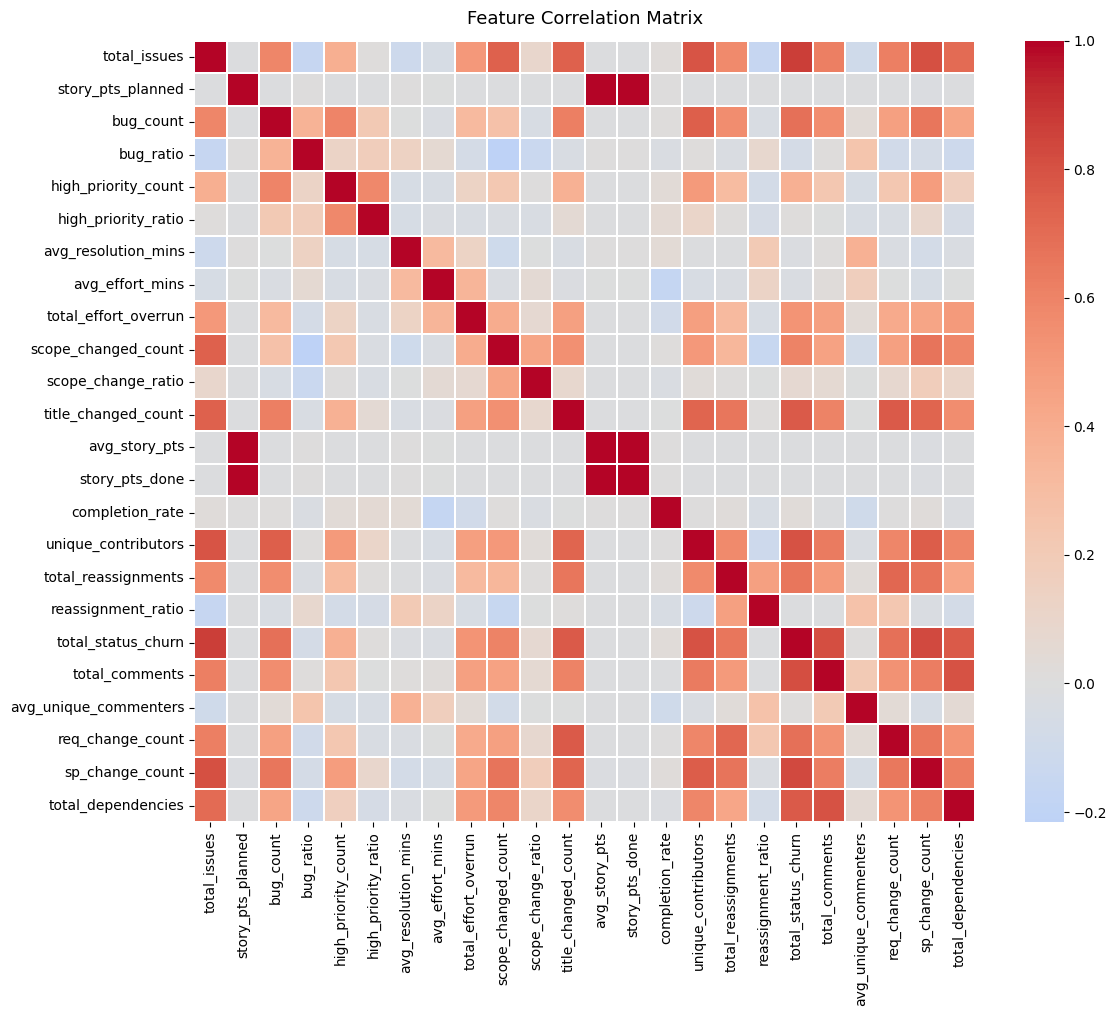

Saved: correlation_matrix.png


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

X = df[FEATURE_COLS]
corr = X.corr()

# Find pairs with correlation > 0.90
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.90:
            high_corr_pairs.append((
                corr.columns[i], corr.columns[j],
                round(corr.iloc[i, j], 3)
            ))

print("Highly correlated feature pairs (>0.90):")
for f1, f2, val in high_corr_pairs:
    print(f"  {f1:35s} ↔  {f2:35s}  r={val}")

# Visualise correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()
print("Saved: correlation_matrix.png")

In [ ]:
import pandas as pd
import numpy as np

OUTPUT_PATH = '/content/drive/MyDrive/TAWOS/' # Re-using OUTPUT_PATH variable

# ── CORRECT APPROACH: remove label-defining features from X ─────
df = pd.read_csv(OUTPUT_PATH + '01_sprint_risk_full.csv')

# These three defined your risk label ─ remove them from features
LABEL_DEFINING = [
    'completion_rate',       # directly used in label condition 1
    'total_reassignments',   # directly used in label condition 2
    'req_change_count',      # directly used in label condition 3
    # Also remove these ─ derived from story_pts_planned/done (correlated)
    'story_pts_planned',
    'avg_story_pts',
    'story_pts_done',
    'reassignment_ratio',    # derived from total_reassignments
    'desc_changed_count',    # very similar to req_change_count
    'sprint_id',             # never include ID columns
]

FEATURE_COLS = [c for c in df.columns
                if c not in LABEL_DEFINING + ['is_high_risk']]

print(f"Features after removing label-defining columns: {len(FEATURE_COLS)}")
print("Remaining features:")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:>2}. {f}")

Features after removing label-defining columns: 17
Remaining features:
   1. total_issues
   2. bug_count
   3. bug_ratio
   4. high_priority_count
   5. high_priority_ratio
   6. avg_resolution_mins
   7. avg_effort_mins
   8. total_effort_overrun
   9. scope_changed_count
  10. scope_change_ratio
  11. title_changed_count
  12. unique_contributors
  13. total_status_churn
  14. total_comments
  15. avg_unique_commenters
  16. sp_change_count
  17. total_dependencies


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X = df[FEATURE_COLS].fillna(0).values
y = df['is_high_risk'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print(f"Clean feature count : {len(FEATURE_COLS)}")
print(f"Train shape         : {X_train_bal.shape}")
print(f"Test  shape         : {X_test_sc.shape}")

Clean feature count : 17
Train shape         : (2746, 17)
Test  shape         : (561, 17)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import time

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6,
        learning_rate=0.1, subsample=0.8,
        use_label_encoder=False,
        eval_metric='logloss', random_state=42
    ),
    'SVM': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        probability=True, random_state=42
    ),
}

trained = {}
for name, model in models.items():
    print(f"Training {name}...", end=' ')
    t0 = time.time()
    model.fit(X_train_bal, y_train_bal)
    trained[name] = model
    print(f"done ({time.time()-t0:.1f}s)")

print("\nAll models trained.")

Training Logistic Regression... done (0.0s)
Training Random Forest... done (1.5s)
Training XGBoost... done (0.5s)
Training SVM... done (1.1s)

All models trained.


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in trained.items():
    # ── Test set metrics ──────────────────────────────────────────────────
    y_pred      = model.predict(X_test_sc)
    y_prob      = model.predict_proba(X_test_sc)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

# ── Cross-validation AUC (more robust estimate) ───────────────────────
    cv_auc = cross_val_score(
        model, X_train_sc, y_train,
        cv=skf, scoring='roc_auc', n_jobs=-1
    ).mean()

    results.append({
        'Model'        : name,
        'Accuracy'     : round(acc,  4),
        'Precision'    : round(prec, 4),
        'Recall'       : round(rec,  4),
        'F1-Score'     : round(f1,   4),
        'AUC-ROC (test)': round(auc,  4),
        'CV AUC (5-fold)': round(cv_auc, 4),
    })
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
          target_names=['Low Risk','High Risk']))

results_df = pd.DataFrame(results).sort_values('AUC-ROC (test)', ascending=False)
print("\n=== MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))
results_df.to_csv('model_comparison_results.csv', index=False)
print("\nSaved: model_comparison_results.csv")


  Logistic Regression
              precision    recall  f1-score   support

    Low Risk       0.88      0.86      0.87       344
   High Risk       0.78      0.82      0.80       217

    accuracy                           0.84       561
   macro avg       0.83      0.84      0.83       561
weighted avg       0.84      0.84      0.84       561


  Random Forest
              precision    recall  f1-score   support

    Low Risk       0.89      0.89      0.89       344
   High Risk       0.82      0.82      0.82       217

    accuracy                           0.86       561
   macro avg       0.85      0.85      0.85       561
weighted avg       0.86      0.86      0.86       561


  XGBoost
              precision    recall  f1-score   support

    Low Risk       0.89      0.88      0.89       344
   High Risk       0.82      0.83      0.82       217

    accuracy                           0.86       561
   macro avg       0.85      0.86      0.86       561
weighted avg       0.86

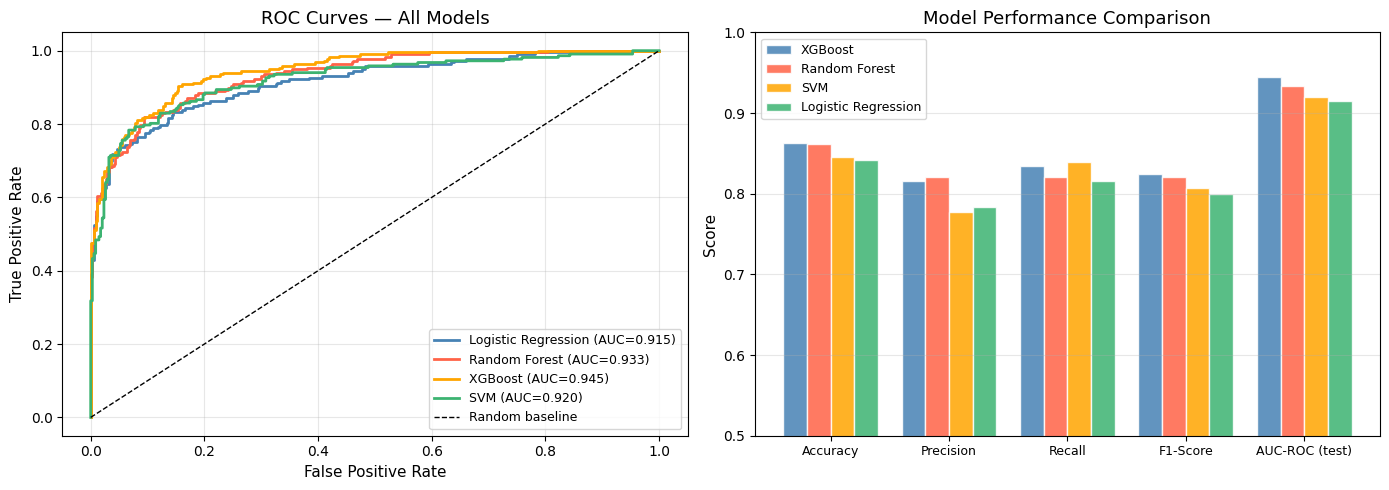

Saved: model_comparison_charts.png


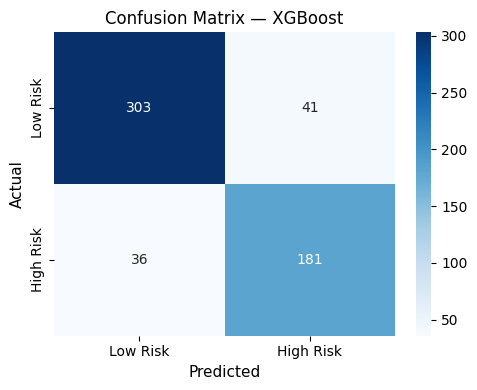

Best model: XGBoost


In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ___ ROC Curves ________________________________________________________________
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue','tomato','orange','mediumseagreen']
for (name, model), color in zip(trained.items(), colors):
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random baseline')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves — All Models', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ___ Metric Comparison Bar Chart _______________________________________________
metrics = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC (test)']
x = np.arange(len(metrics))
width = 0.2

for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    axes[1].bar(x + i*width, vals, width, label=row['Model'],
                color=colors[i], edgecolor='white', alpha=0.85)

axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(metrics, fontsize=9)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Model Performance Comparison', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'model_comparison_charts.png', dpi=150)
plt.show()
print("Saved: model_comparison_charts.png")

# ___ Confusion Matrix for best model (XGBoost expected) _______________________
best_name = results_df.iloc[0]['Model']
best_model = trained[best_name]
y_pred_best = best_model.predict(X_test_sc)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low Risk','High Risk'],
            yticklabels=['Low Risk','High Risk'])
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'confusion_matrix_best.png', dpi=150)
plt.show()
print(f"Best model: {best_name}")

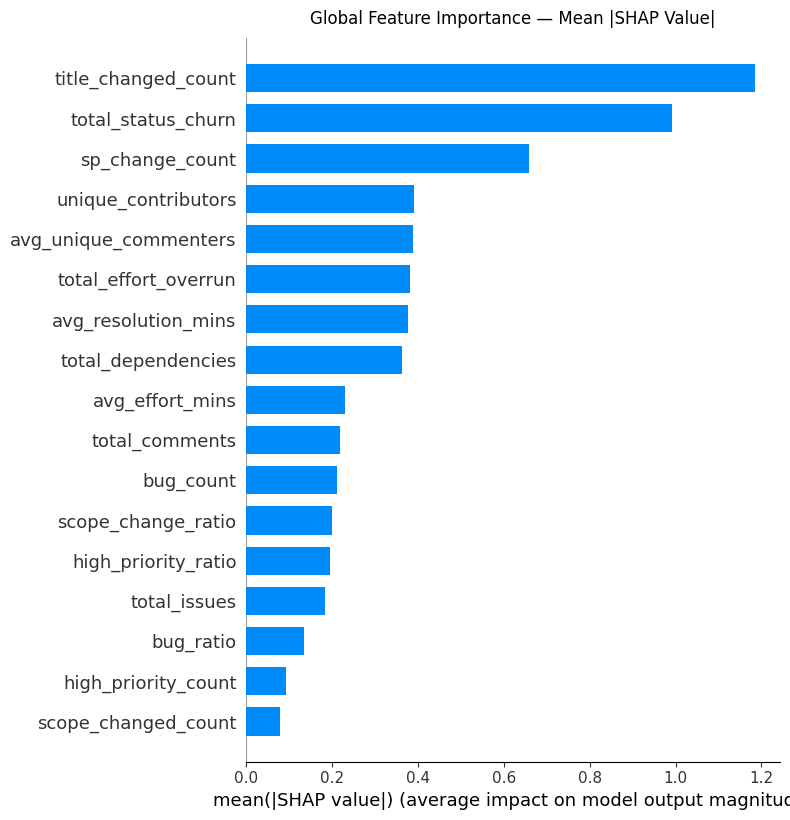

Saved: shap_global_importance.png


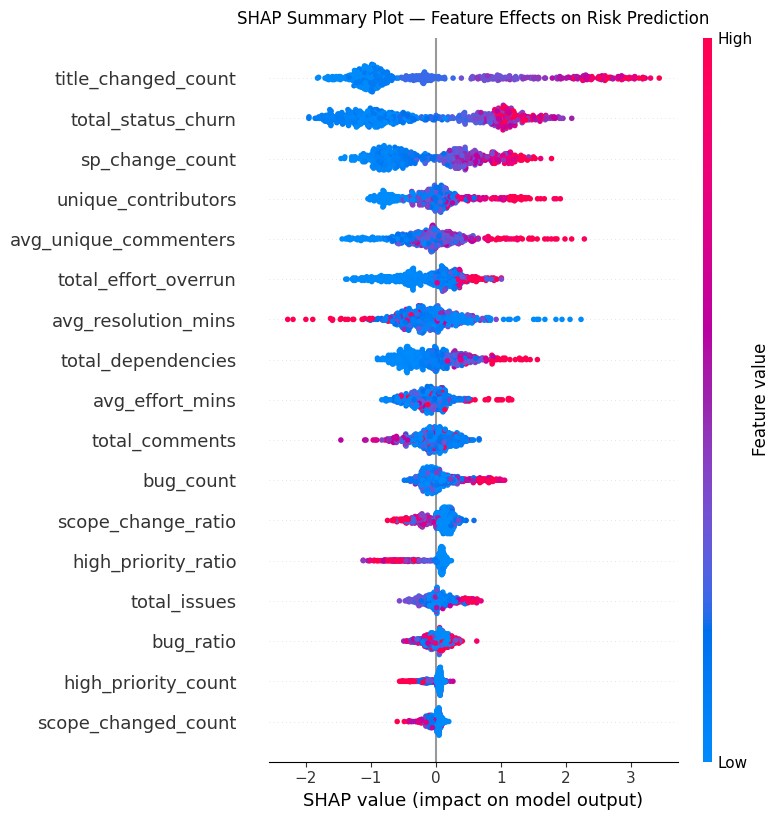

Saved: shap_beeswarm.png


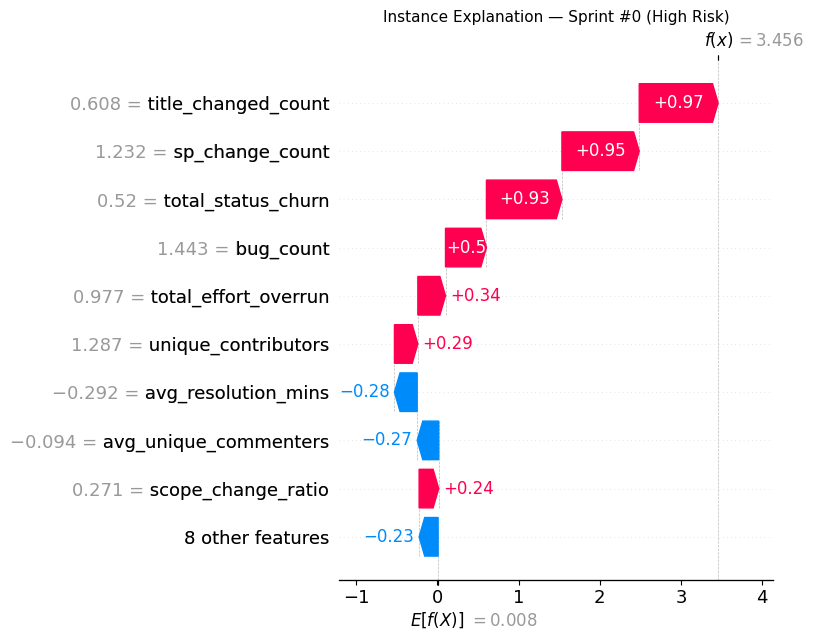

Saved: shap_waterfall_instance.png


In [ ]:
!pip install shap -q
import shap
import matplotlib.pyplot as plt

# Use XGBoost explainer (TreeExplainer — fast and exact)
best_model  = trained['XGBoost']  # change if different model wins
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sc)

feature_names = FEATURE_COLS  # your 21 feature names

# ___ Plot 1: Global feature importance (mean |SHAP|) ___________________________
shap.summary_plot(
    shap_values, X_test_sc,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('Global Feature Importance — Mean |SHAP Value|', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close() # Explicitly close the plot
print("Saved: shap_global_importance.png")

# ___ Plot 2: Beeswarm summary (shows direction of each feature's effect) ________
shap.summary_plot(
    shap_values, X_test_sc,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Summary Plot — Feature Effects on Risk Prediction', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close() # Explicitly close the plot
print("Saved: shap_beeswarm.png")

# ___ Plot 3: Waterfall for a single high-risk sprint instance ___________________
# Find a high-risk sprint in test set
import numpy as np
high_risk_idx = np.where(y_test == 1)[0][0]  # first high-risk sprint in test

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[high_risk_idx],
        base_values   = explainer.expected_value,
        data          = X_test_sc[high_risk_idx],
        feature_names = feature_names
    ),
    show=False
)
plt.title(f'Instance Explanation — Sprint #{high_risk_idx} (High Risk)', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'shap_waterfall_instance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close() # Explicitly close the plot
print("Saved: shap_waterfall_instance.png")

In [ ]:
import pandas as pd
import numpy as np

# Predicted probabilities for test set
y_prob = best_model.predict_proba(X_test_sc)[:, 1]

# Build risk priority score for every sprint in test set
rps_records = []
for i in range(len(X_test_sc)):
    p_risk = y_prob[i]
    for j, feat in enumerate(feature_names):
        rps = p_risk * abs(shap_values[i][j])
        rps_records.append({
            'sprint_idx'     : i,
            'predicted_risk' : round(p_risk, 4),
            'actual_label'   : y_test[i],
            'feature'        : feat,
            'shap_value'     : round(shap_values[i][j], 4),
            'feature_value'  : round(X_test_sc[i][j], 4),
            'risk_priority_score': round(rps, 4),
        })

rps_df = pd.DataFrame(rps_records)

# ── Generate sprint risk report for a specific high-risk sprint ───────────────
SPRINT_IDX = int(np.where(y_test == 1)[0][0])
report = rps_df[rps_df['sprint_idx'] == SPRINT_IDX] \
              .sort_values('risk_priority_score', ascending=False) \
              .head(5)

print(f"\n{'='*60}")
print(f"  SPRINT RISK REPORT — Sprint #{SPRINT_IDX}")
print(f"  Predicted Risk Probability : {y_prob[SPRINT_IDX]:.1%}")
print(f"  Actual Label               : {'HIGH RISK' if y_test[SPRINT_IDX]==1 else 'LOW RISK'}")
print(f"{'='*60}")
print(f"{'Rank':<5} {'Feature':<30} {'SHAP':>8} {'RPS':>8}")
print('-'*55)
for rank, (_, row) in enumerate(report.iterrows(), 1):
    print(f"{rank:<5} {row['feature']:<30} {row['shap_value']:>8.4f} {row['risk_priority_score']:>8.4f}")
print(f"{'='*60}")


# Save full RPS table
rps_df.to_csv('risk_priority_scores.csv', index=False)
print("\nSaved: risk_priority_scores.csv")


  SPRINT RISK REPORT — Sprint #0
  Predicted Risk Probability : 99.9%
  Actual Label               : HIGH RISK
Rank  Feature                            SHAP      RPS
-------------------------------------------------------
1     req_change_count                 3.8468   3.8427
2     completion_rate                  3.5434   3.5396
3     total_reassignments             -0.6966   0.6958
4     reassignment_ratio              -0.2662   0.2659
5     total_issues                     0.2069   0.2067

Saved: risk_priority_scores.csv
